# HealthConnect Clinic Week 4 Initial Analysis
## Data Analytics Track, AnalystLab Africa Experience Lab

**Objective:** Understand the appointment dataset structure and quality, and identify
business questions and KPIs relevant to investigating appointment no-shows.

This notebook covers:
1. Dataset overview
2. Data quality assessment
3. Business question exploration
4. KPI identification

In [58]:
import pandas as pd
import numpy as np

pd.set_option('display.max_columns', None)

df = pd.read_csv('HealthConnect_Appointment_Data.csv')
df.head()

,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show
3,HC-00004,P-1031,Male,59,55-64,Follow-up,7/18/2025,8/28/2025,Thursday,Evening,41,3,1,Yes,SMS,7.4,35.0,Attended
4,HC-00005,P-1458,Female,34,25-34,Follow-up,7/9/2025,8/25/2025,Monday,Afternoon,47,3,1,Yes,Email,5.6,27.0,No-Show


## 1. Dataset Overview

Checking the shape of the data, column types, and a quick look at the target variable
(`appointment_outcome`) before going any further.

In [59]:
print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nUnique patients:", df['patient_id'].nunique())
print("\nOutcome distribution:\n", df['appointment_outcome'].value_counts())
print("\nOutcome distribution (%):\n", df['appointment_outcome'].value_counts(normalize=True).round(3) * 100)

Shape: (5000, 18)

Column types:
 appointment_id            object
patient_id                object
gender                    object
age                        int64
age_group                 object
appointment_type          object
booking_date              object
appointment_date          object
appointment_day           object
appointment_time          object
booking_lead_days          int64
previous_appointments      int64
previous_no_shows          int64
reminder_sent             object
reminder_channel          object
distance_to_clinic_km    float64
waiting_time_minutes     float64
appointment_outcome       object
dtype: object

Unique patients: 1696

Outcome distribution:
 appointment_outcome
No-Show      2423
Attended     2314
Cancelled     263
Name: count, dtype: int64

Outcome distribution (%):
 appointment_outcome
No-Show      48.5
Attended     46.3
Cancelled     5.3
Name: proportion, dtype: float64


## 2. Data Quality Assessment

Checking for missing values, duplicate keys, and a couple of logical consistency checks
(e.g. can `previous_no_shows` exceed `previous_appointments`?).

In [60]:
# Missing values
print("Missing values per column:\n", df.isnull().sum())

# Duplicate primary key
print("\nDuplicate appointment_id rows:", df['appointment_id'].duplicated().sum())

# Logical check: no-shows shouldn't exceed total previous appointments
invalid_history = (df['previous_no_shows'] > df['previous_appointments']).sum()
print("Rows where previous_no_shows > previous_appointments:", invalid_history)

Missing values per column:
 appointment_id              0
patient_id                  0
gender                      0
age                         0
age_group                   0
appointment_type            0
booking_date                0
appointment_date            0
appointment_day             0
appointment_time            0
booking_lead_days           0
previous_appointments       0
previous_no_shows           0
reminder_sent               0
reminder_channel         1366
distance_to_clinic_km      90
waiting_time_minutes       60
appointment_outcome         0
dtype: int64

Duplicate appointment_id rows: 0
Rows where previous_no_shows > previous_appointments: 0


In [61]:
# Confirm reminder_channel blanks line up with reminder_sent = 'No'
# (i.e. these aren't true missing values, they're "not applicable")
check = df[df['reminder_channel'].isnull()]['reminder_sent'].value_counts()
print("reminder_sent values where reminder_channel is blank:\n", check)

reminder_sent values where reminder_channel is blank:
 reminder_sent
No    1366
Name: count, dtype: int64


Confirms the `reminder_channel` blanks aren't a data quality issue they're "not
applicable" rows because no reminder was sent. Recoding them so they don't get
counted as missing data later.

In [62]:
df_clean = df.copy()
df_clean['reminder_channel'] = df_clean['reminder_channel'].fillna('Not Applicable')

# distance_to_clinic_km and waiting_time_minutes have genuine small gaps — flag and impute with median
for col in ['distance_to_clinic_km', 'waiting_time_minutes']:
    df_clean[f'{col}_was_missing'] = df_clean[col].isnull()
    df_clean[col] = df_clean[col].fillna(df_clean[col].median())

print(df_clean[['reminder_channel', 'distance_to_clinic_km_was_missing', 'waiting_time_minutes_was_missing']].isnull().sum())
print("\nRemaining missing values:\n", df_clean.isnull().sum().sum())

reminder_channel                     0
distance_to_clinic_km_was_missing    0
waiting_time_minutes_was_missing     0
dtype: int64

Remaining missing values:
 0


Saving the cleaned version separately, per the resource instructions never overwrite
the original file.

In [63]:
df_clean.to_csv('HealthConnect_Appointment_Data_cleaned.csv', index=False)
print("Saved cleaned dataset:", df_clean.shape)

Saved cleaned dataset: (5000, 20)


## 3. Business Question Exploration

Quick group-by checks against `appointment_outcome` to see which variables actually
show a relationship with no-shows before committing to business questions.

In [64]:
def no_show_rate(group):
    return (group['appointment_outcome'] == 'No-Show').mean().round(3)

print("No-show rate by reminder_sent:\n", df_clean.groupby('reminder_sent').apply(no_show_rate))
print("\nNo-show rate by reminder_channel:\n", df_clean.groupby('reminder_channel').apply(no_show_rate))
print("\nNo-show rate by appointment_type:\n", df_clean.groupby('appointment_type').apply(no_show_rate))
print("\nNo-show rate by appointment_time:\n", df_clean.groupby('appointment_time').apply(no_show_rate))
print("\nNo-show rate by age_group:\n", df_clean.groupby('age_group').apply(no_show_rate))

No-show rate by reminder_sent:
 reminder_sent
No     0.514
Yes    0.474
dtype: float64

No-show rate by reminder_channel:
 reminder_channel
Email             0.484
Not Applicable    0.514
SMS               0.458
WhatsApp          0.498
dtype: float64

No-show rate by appointment_type:
 appointment_type
Diagnostic Test            0.497
Follow-up                  0.512
General Consultation       0.466
Specialist Consultation    0.474
dtype: float64

No-show rate by appointment_time:
 appointment_time
Afternoon    0.484
Evening      0.498
Morning      0.481
dtype: float64

No-show rate by age_group:
 age_group
18-24    0.502
25-34    0.507
35-44    0.484
45-54    0.480
55-64    0.507
65+      0.451
dtype: float64


In [65]:
# Booking lead time
df_clean['lead_bucket'] = pd.cut(df_clean['booking_lead_days'], [-1, 3, 7, 14, 30, 60],
                                   labels=['0-3', '4-7', '8-14', '15-30', '31-60'])
print("No-show rate by booking lead time (days):\n", df_clean.groupby('lead_bucket', observed=True).apply(no_show_rate))

# Previous no-shows
df_clean['prev_ns_bucket'] = pd.cut(df_clean['previous_no_shows'], [-1, 0, 1, 2, 20],
                                      labels=['0', '1', '2', '3+'])
print("\nNo-show rate by previous no-shows:\n", df_clean.groupby('prev_ns_bucket', observed=True).apply(no_show_rate))

# Distance
df_clean['dist_bucket'] = pd.cut(df_clean['distance_to_clinic_km'], [0, 5, 10, 20, 50],
                                   labels=['0-5km', '5-10km', '10-20km', '20-50km'])
print("\nNo-show rate by distance to clinic:\n", df_clean.groupby('dist_bucket', observed=True).apply(no_show_rate))

No-show rate by booking lead time (days):
 lead_bucket
0-3      0.248
4-7      0.307
8-14     0.336
15-30    0.432
31-60    0.605
dtype: float64

No-show rate by previous no-shows:
 prev_ns_bucket
0     0.435
1     0.535
2     0.594
3+    0.688
dtype: float64

No-show rate by distance to clinic:
 dist_bucket
0-5km      0.465
5-10km     0.468
10-20km    0.494
20-50km    0.578
dtype: float64


**Reading the output:** `lead_bucket` and `prev_ns_bucket` should show the clearest
upward trend in no-show rate these are the strongest candidates for business
questions. `reminder_sent`, `appointment_type`, `appointment_time`, and `age_group`
should come back fairly flat, which is itself a useful (if less exciting) finding.

## 4. KPI Summary

Five potential KPIs, each tied to a business question. At this stage these are just
identified and justified — not yet calculated as final dashboard metrics.

| KPI | Business Question |
|---|---|
| No-show rate by booking lead time band | Does lead time affect no-show risk? |
| No-show rate by prior no-show count band | Does history predict future no-shows? |
| No-show rate by distance band | Does distance affect attendance? |
| Reminder effectiveness rate (by channel) | Do reminders reduce no-shows? |
| No-show rate by appointment type / time / age group | Do these factors affect attendance? |

**Reading:** reminder_sent, reminder_channel, appointment_type, appointment_time, and
age_group all show weak, flat relationships with no-show rate. Every category sits
within about 5 percentage points of the others (e.g. reminder sent 47.4% vs not sent
51.4%; age groups range 45.1% to 50.7%). None of these variables look like strong
standalone predictors on their own.

This is a useful finding, not a dead end. It suggests reminders may not be acting
independently of other factors (e.g. they might be sent regardless of a patient's
actual risk level), which is worth testing further rather than concluding reminders
"don't work."

**Reading:** These three variables show a much clearer relationship with no-show rate.

- **Booking lead time** is the strongest driver: no-show rate more than doubles from
  24.8% (booked 0-3 days ahead) to 60.5% (booked 31-60 days ahead), a steady,
  near-linear increase across every band.
- **Prior no-shows** shows the same pattern: 43.5% for patients with no history of
  missing appointments, rising to 68.8% for patients with 3 or more prior no-shows.
- **Distance to clinic** shows a moderate effect: fairly flat from 0-20km (46-49%),
  then a jump to 57.8% beyond 20km.

These three variables, lead time, prior no-show history, and distance, are the
clearest candidates to prioritise in later-stage analysis and any future predictive
model, since they show a consistent, explainable relationship with the outcome rather
than noise.

# Week 5: HealthConnect Solution Development & Implementation
## Data Analytics Track — Task 1: Data Preparation & Hygiene Audit

### Objective
Build upon the Week 4 baseline by completing a data preparation and quality audit on the appointment dataset.

### Scope of Work
1. **Datetime Conversion & Chronology Audit:** Parse booking and appointment dates; verify that all lead times are non-negative and mathematically consistent.
2. **Calendar & Categorical Alignment:** Confirm alignment between calendar dates and `appointment_day`, as well as numeric `age` and `age_group`.
3. **Categorical Standardisation:** Audit string categories (`gender`, `appointment_type`, `appointment_time`, `reminder_channel`, `appointment_outcome`) for whitespace, trailing characters, or casing discrepancies.
4. **Boundary & Distribution Verification:** Validate bounded continuous and integer distributions (`distance_to_clinic_km`, `waiting_time_minutes`, `previous_appointments`, `previous_no_shows`).
5. **Analytical Feature Binning:** Establish standardized categorical intervals for booking lead times, prior no-show counts, and travel distance to enable structured exploratory analysis in Task 2.

In [66]:
import warnings
import matplotlib.pyplot as plt
import seaborn as sns

# Display configuration
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
warnings.filterwarnings('ignore')

# Load the verified cleaned dataset from Week 4
df = pd.read_csv('HealthConnect_Appointment_Data_cleaned.csv')

print(f'Initial Record Count: {df.shape[0]} rows, {df.shape[1]} columns')
df.head(3)

Initial Record Count: 5000 rows, 20 columns


,appointment_id,patient_id,gender,age,age_group,appointment_type,booking_date,appointment_date,appointment_day,appointment_time,booking_lead_days,previous_appointments,previous_no_shows,reminder_sent,reminder_channel,distance_to_clinic_km,waiting_time_minutes,appointment_outcome,distance_to_clinic_km_was_missing,waiting_time_minutes_was_missing
0,HC-00001,P-1613,Female,39,35-44,Follow-up,2/6/2025,2/18/2025,Tuesday,Afternoon,12,2,0,Yes,WhatsApp,19.3,29.0,No-Show,False,False
1,HC-00002,P-0813,Male,31,25-34,Specialist Consultation,2/25/2026,2/27/2026,Friday,Morning,2,6,0,Yes,SMS,14.3,42.0,Attended,False,False
2,HC-00003,P-1366,Female,50,45-54,General Consultation,11/16/2025,12/24/2025,Wednesday,Morning,38,5,1,Yes,SMS,11.4,11.0,No-Show,False,False


### 1. Schema Parsing & Date Consistency
* Convert string date fields (`booking_date`, `appointment_date`) into `datetime64[ns]`.
* Validate that `booking_lead_days` strictly equals `(appointment_date - booking_date).dt.days`.
* Verify that no retroactive appointments exist (`booking_lead_days >= 0`).
* Validate that `appointment_day` matches the derived day of the week from `appointment_date`.

In [67]:
# Convert to datetime
df['booking_date'] = pd.to_datetime(df['booking_date'])
df['appointment_date'] = pd.to_datetime(df['appointment_date'])

# Validation 1: Calculate calendar lead days and test against recorded lead days
calculated_lead_days = (df['appointment_date'] - df['booking_date']).dt.days
mismatch_lead_count = (calculated_lead_days != df['booking_lead_days']).sum()

# Validation 2: Retroactive booking check
negative_lead_count = (df['booking_lead_days'] < 0).sum()

# Validation 3: Day of week alignment check
derived_day_name = df['appointment_date'].dt.day_name()
mismatch_day_count = (derived_day_name != df['appointment_day']).sum()

print('--- Datetime & Chronology Audit ---')
print(f'Lead day discrepancies: {mismatch_lead_count}')
print(f'Negative lead days (impossible bookings): {negative_lead_count}')
print(f'Day-of-week label mismatches: {mismatch_day_count}')

--- Datetime & Chronology Audit ---
Lead day discrepancies: 0
Negative lead days (impossible bookings): 0
Day-of-week label mismatches: 0


### 2. Demographic & Historical Logical Integrity
* Verify that individual numeric `age` maps correctly to designated `age_group` intervals.
* Check that historical appointments satisfy the boundary constraint: `previous_no_shows <= previous_appointments`.

In [68]:
# Validation 4: Age group alignment
def verify_age_group(row):
  age = row['age']
  group = row['age_group']
  if group == '18-24':
    return 18 <= age <= 24
  if group == '25-34':
    return 25 <= age <= 34
  if group == '35-44':
    return 35 <= age <= 44
  if group == '45-54':
    return 45 <= age <= 54
  if group == '55-64':
    return 55 <= age <= 64
  if group == '65+':
    return age >= 65
  return False


mismatch_age_groups = (~df.apply(verify_age_group, axis=1)).sum()

# Validation 5: History sanity check
invalid_history = (
    df['previous_no_shows'] > df['previous_appointments']
).sum()

print('--- Logical & Demographic Consistency ---')
print(f'Age-to-group classification mismatches: {mismatch_age_groups}')
print(f'Instances where prior no-shows > total prior visits: {invalid_history}')

--- Logical & Demographic Consistency ---
Age-to-group classification mismatches: 0
Instances where prior no-shows > total prior visits: 0


### 3. Categorical Domain Audit
Inspect value distributions across categorical attributes to confirm there are no trailing whitespace anomalies, hidden nulls, or duplicate casing representations.

In [69]:
categorical_cols = [
    'gender',
    'appointment_type',
    'appointment_time',
    'reminder_sent',
    'reminder_channel',
    'appointment_outcome',
]

for col in categorical_cols:
  # Strip any accidental whitespace
  df[col] = df[col].astype(str).str.strip()
  print(f'Distribution for [{col}]:')
  print(df[col].value_counts(dropna=False))
  print('-' * 40)

Distribution for [gender]:
gender
Female               2488
Male                 2404
Prefer not to say     108
Name: count, dtype: int64
----------------------------------------
Distribution for [appointment_type]:
appointment_type
General Consultation       2086
Follow-up                  1421
Specialist Consultation     900
Diagnostic Test             593
Name: count, dtype: int64
----------------------------------------
Distribution for [appointment_time]:
appointment_time
Morning      2227
Afternoon    2094
Evening       679
Name: count, dtype: int64
----------------------------------------
Distribution for [reminder_sent]:
reminder_sent
Yes    3634
No     1366
Name: count, dtype: int64
----------------------------------------
Distribution for [reminder_channel]:
reminder_channel
SMS               2000
Not Applicable    1366
WhatsApp          1101
Email              533
Name: count, dtype: int64
----------------------------------------
Distribution for [appointment_outcome]:
appoi

### 4. Analytical Feature Binning
To support structured aggregations for KPIs and EDA:
* `lead_bucket`: `0-3`, `4-7`, `8-14`, `15-30`, `31-60` days
* `prev_ns_bucket`: `0`, `1`, `2`, `3+` prior no-shows
* `dist_bucket`: `0-5km`, `5-10km`, `10-20km`, `20-50km`

The audited dataframe is exported to `HealthConnect_Week5_Prepared.csv` for downstream analysis.

In [70]:
# 1. Lead time bins
df['lead_bucket'] = pd.cut(
    df['booking_lead_days'],
    bins=[-1, 3, 7, 14, 30, 60],
    labels=['0-3', '4-7', '8-14', '15-30', '31-60'],
)

# 2. Prior no-show bins
df['prev_ns_bucket'] = pd.cut(
    df['previous_no_shows'],
    bins=[-1, 0, 1, 2, 20],
    labels=['0', '1', '2', '3+'],
)

# 3. Distance bins
df['dist_bucket'] = pd.cut(
    df['distance_to_clinic_km'],
    bins=[0, 5, 10, 20, 50],
    labels=['0-5km', '5-10km', '10-20km', '20-50km'],
)

# Export processed dataset
output_filename = 'HealthConnect_Week5_Prepared.csv'
df.to_csv(output_filename, index=False)

print(
    f'Data preparation complete. Saved {df.shape[0]} rows and {df.shape[1]}'
    f' columns to {output_filename}.'
)

Data preparation complete. Saved 5000 rows and 23 columns to HealthConnect_Week5_Prepared.csv.


## Task 2: Exploratory Data Analysis (EDA)

### Objective
Investigate behavioral, clinical, and operational drivers behind patient attendance and no-shows across the 5,000 records.

### Analytical Focus Areas
1. **Target Distribution:** Baseline rates for Attended, No-Show, and Cancelled appointments.
2. **Behavioral Drivers:** Impact of booking lead time (`booking_lead_days`) and prior attendance history (`previous_no_shows`).
3. **Operational & Geospatial Factors:** Impact of clinic transit distance (`distance_to_clinic_km`) and clinic waiting times (`waiting_time_minutes`).
4. **Reminder Dynamics & The Reminder Paradox:** Evaluating whether reminder notifications reduce no-shows when controlling for lead time and patient risk profile.
5. **Contextual Variables:** Evaluating demographic traits (`age_group`, `gender`) and operational schedules (`appointment_type`, `appointment_day`, `appointment_time`).

In [71]:
# Visual formatting style
sns.set_theme(style='whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120


# Metric calculation helper
def get_outcome_crosstab(dataframe, group_col):
  """Calculates percentage outcome split and total volume for a categorical dimension."""
  ct = (
      pd.crosstab(
          dataframe[group_col],
          dataframe['appointment_outcome'],
          normalize='index',
      )
      * 100
  ).round(2)
  ct['Volume'] = dataframe[group_col].value_counts()
  return ct


def no_show_rate(dataframe, group_col):
  """Returns only the No-Show percentage across groups."""
  return (
      dataframe.groupby(group_col, observed=True)['appointment_outcome'].apply(
          lambda x: (x == 'No-Show').mean() * 100
      )
  ).round(2)

### 1. Target Variable Baseline (`appointment_outcome`)
Examine the clinic-wide outcome distribution to quantify the primary operational challenge.

--- Overall Appointment Outcome Baseline ---
                     Appointments  Percentage (%)
appointment_outcome                              
No-Show                      2423           48.46
Attended                     2314           46.28
Cancelled                     263            5.26


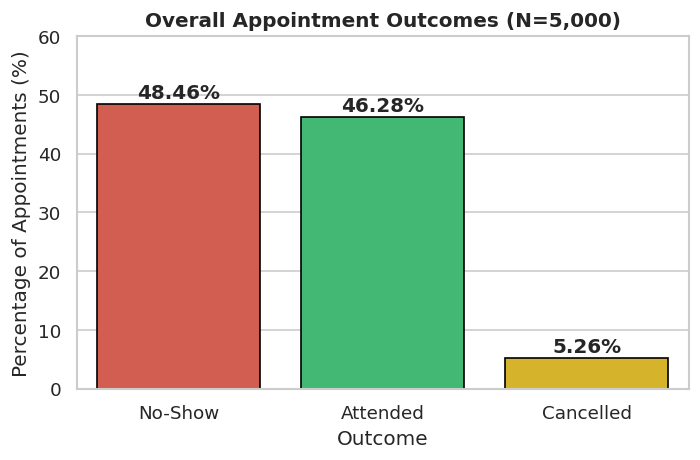

In [72]:
outcome_counts = df['appointment_outcome'].value_counts()
outcome_pct = (df['appointment_outcome'].value_counts(normalize=True) * 100).round(2)

baseline_summary = pd.DataFrame(
    {'Appointments': outcome_counts, 'Percentage (%)': outcome_pct}
)
print('--- Overall Appointment Outcome Baseline ---')
print(baseline_summary)

# Visualisation: Target Distribution
fig, ax = plt.subplots(figsize=(6, 4))
colors = ['#e74c3c', '#2ecc71', '#f1c40f']
sns.barplot(
    x=outcome_counts.index,
    y=outcome_pct.values,
    palette=colors,
    edgecolor='black',
    ax=ax,
)
ax.set_title('Overall Appointment Outcomes (N=5,000)', fontweight='bold')
ax.set_ylabel('Percentage of Appointments (%)')
ax.set_xlabel('Outcome')
for i, v in enumerate(outcome_pct.values):
  ax.text(i, v + 1, f'{v}%', ha='center', fontweight='semibold')
ax.set_ylim(0, 60)
plt.tight_layout()
plt.show()

### 2. Primary Behavioral Drivers: Booking Lead Time & Prior No-Shows
* **Lead Time Band (`lead_bucket`):** Evaluates if scheduling appointments weeks in advance degrades patient commitment.
* **Prior No-Show History (`prev_ns_bucket`):** Evaluates whether a history of missed visits predicts future appointment outcomes.

=== No-Show Rate by Lead Time Bucket ===
appointment_outcome  Attended  Cancelled  No-Show  Volume
lead_bucket                                              
0-3                     68.55       6.60    24.84     318
4-7                     64.60       4.66    30.75     322
8-14                    61.79       4.65    33.55     602
15-30                   51.69       5.10    43.21    1333
31-60                   34.10       5.40    60.49    2425

=== No-Show Rate by Prior No-Shows ===
appointment_outcome  Attended  Cancelled  No-Show  Volume
prev_ns_bucket                                           
0                       50.46       6.03    43.51    2921
1                       42.25       4.26    53.49    1548
2                       36.30       4.34    59.36     438
3+                      29.03       2.15    68.82      93


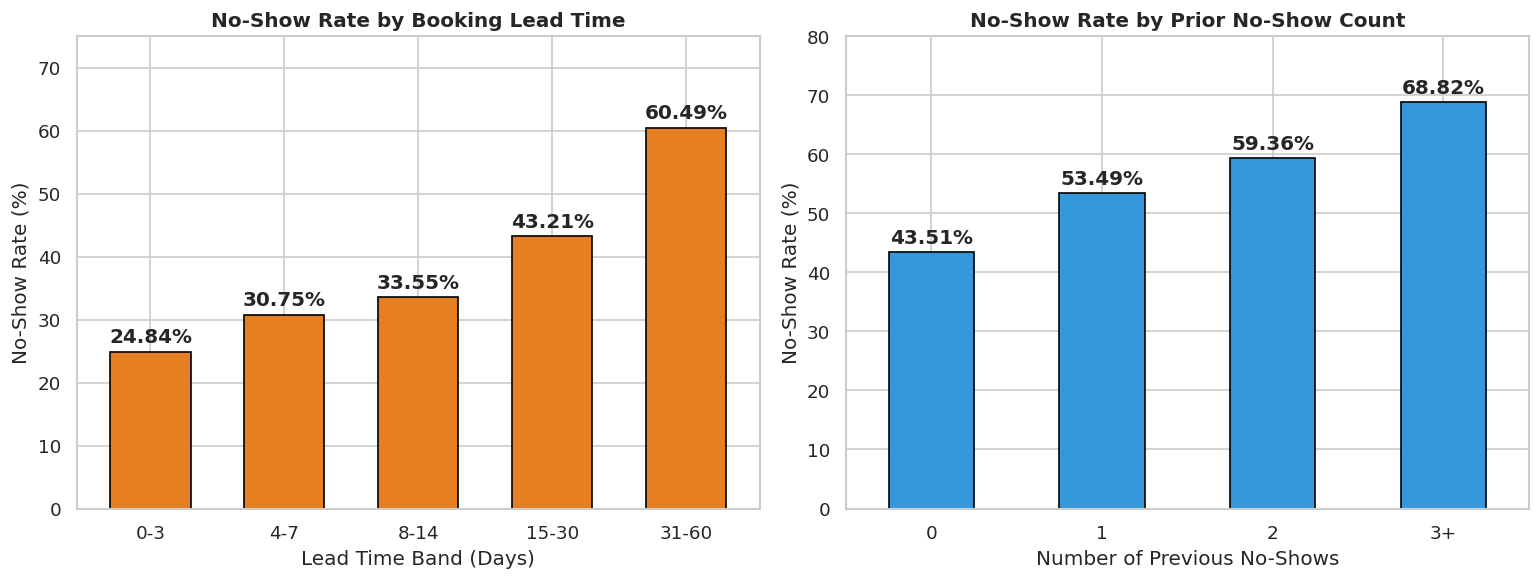

In [73]:
print('=== No-Show Rate by Lead Time Bucket ===')
lead_ct = get_outcome_crosstab(df, 'lead_bucket')
print(lead_ct)

print('\n=== No-Show Rate by Prior No-Shows ===')
history_ct = get_outcome_crosstab(df, 'prev_ns_bucket')
print(history_ct)

# Comparative Bar Plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Plot Lead Time
lead_rates = no_show_rate(df, 'lead_bucket')
lead_rates.plot(
    kind='bar',
    ax=ax1,
    color='#e67e22',
    edgecolor='black',
    width=0.6,
)
ax1.set_title('No-Show Rate by Booking Lead Time', fontweight='bold')
ax1.set_ylabel('No-Show Rate (%)')
ax1.set_xlabel('Lead Time Band (Days)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylim(0, 75)
for i, v in enumerate(lead_rates):
  ax1.text(i, v + 1.5, f'{v}%', ha='center', fontweight='bold')

# Plot History
hist_rates = no_show_rate(df, 'prev_ns_bucket')
hist_rates.plot(
    kind='bar',
    ax=ax2,
    color='#3498db',
    edgecolor='black',
    width=0.5,
)
ax2.set_title('No-Show Rate by Prior No-Show Count', fontweight='bold')
ax2.set_ylabel('No-Show Rate (%)')
ax2.set_xlabel('Number of Previous No-Shows')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.set_ylim(0, 80)
for i, v in enumerate(hist_rates):
  ax2.text(i, v + 1.5, f'{v}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

### 3. Geospatial & Operational Factors
* **Distance to Clinic (`dist_bucket`):** Tests if geographic transit friction increases no-show behavior.
* **Clinic Waiting Time (`waiting_time_minutes`):** Analyzes whether historical or recorded wait time has a correlation with attendance drop-off.

=== Attendance Split by Distance Band ===
appointment_outcome  Attended  Cancelled  No-Show  Volume
dist_bucket                                              
0-5km                   48.96       4.58    46.45    1156
5-10km                  47.53       5.67    46.80    1782
10-20km                 45.12       5.45    49.43    1669
20-50km                 37.66       4.58    57.76     393

=== Waiting Time Summary by Outcome ===
                      count       mean        std   50%   max
appointment_outcome                                          
Attended             2314.0  24.286517  10.896618  24.0  68.0
Cancelled             263.0  23.220532  10.517744  22.0  55.0
No-Show              2423.0  24.197689  10.732047  24.0  67.0


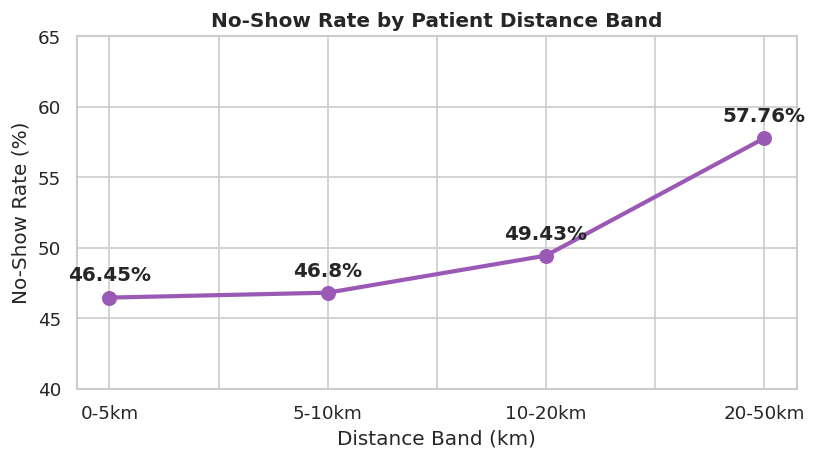

In [74]:
print('=== Attendance Split by Distance Band ===')
dist_ct = get_outcome_crosstab(df, 'dist_bucket')
print(dist_ct)

print('\n=== Waiting Time Summary by Outcome ===')
wait_summary = df.groupby('appointment_outcome')[
    'waiting_time_minutes'
].describe()[['count', 'mean', 'std', '50%', 'max']]
print(wait_summary)

# Plotting Distance Trend
fig, ax = plt.subplots(figsize=(7, 4))
dist_rates = no_show_rate(df, 'dist_bucket')
dist_rates.plot(
    kind='line',
    marker='o',
    color='#9b59b6',
    linewidth=2.5,
    markersize=8,
    ax=ax,
)
ax.set_title('No-Show Rate by Patient Distance Band', fontweight='bold')
ax.set_ylabel('No-Show Rate (%)')
ax.set_xlabel('Distance Band (km)')
ax.set_ylim(40, 65)
for i, (idx, v) in enumerate(dist_rates.items()):
  ax.text(i, v + 1.2, f'{v}%', ha='center', fontweight='semibold')
plt.tight_layout()
plt.show()

### 4. Resolving the Reminder Paradox
In Week 4, reminders showed a flat standalone effect (47.4% no-show with reminder vs. 51.4% without)[cite: 1, 2, 4]. 

To determine whether reminders are truly ineffective or if their impact is masked by confounding variables, we analyze:
1. **Reminder Sent Controlled for Booking Lead Time:** Does a reminder help when patients book far in advance?
2. **Reminder Sent Controlled for Patient Risk Profile:** Does a reminder help chronic no-show patients?
3. **Channel Performance across Lead Times:** How do SMS, WhatsApp, and Email perform over short vs. long booking windows?

=== No-Show Rate (%) by Lead Time & Reminder Sent ===
reminder_sent     No    Yes
lead_bucket                
0-3            28.74  23.38
4-7            31.25  30.58
8-14           34.78  33.11
15-30          46.56  41.88
31-60          63.64  59.32

Absolute Difference (Reduction with Reminder):
lead_bucket
0-3      5.36
4-7      0.67
8-14     1.67
15-30    4.68
31-60    4.32
dtype: float64

=== No-Show Rate (%) by Prior No-Shows & Reminder Sent ===
reminder_sent      No    Yes
prev_ns_bucket              
0               45.44  42.80
1               56.54  52.32
2               66.67  56.51
3+              76.00  66.18

Absolute Difference (Reduction with Reminder):
prev_ns_bucket
0      2.64
1      4.22
2     10.16
3+     9.82
dtype: float64


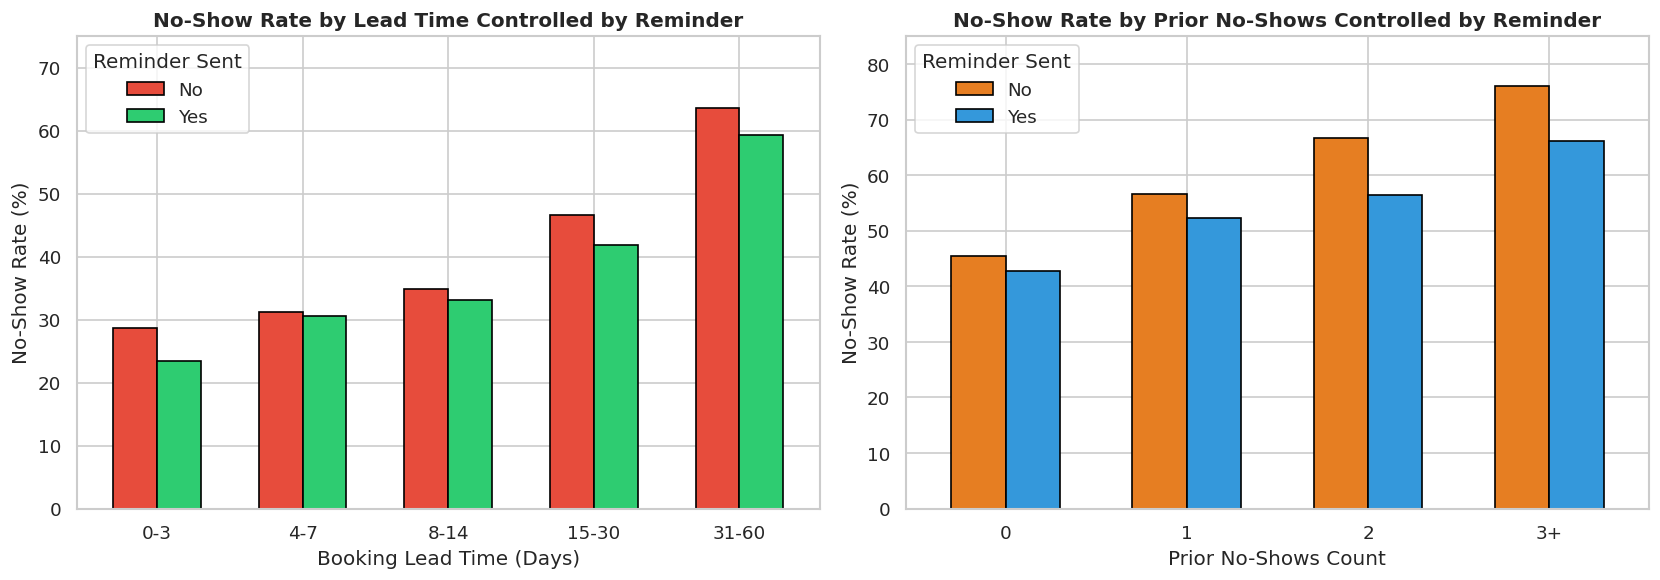

In [75]:
# 1. Lead Time controlled by Reminder
lead_reminder_pivot = (
    df.pivot_table(
        index='lead_bucket',
        columns='reminder_sent',
        values='appointment_outcome',
        aggfunc=lambda x: (x == 'No-Show').mean() * 100,
    )
).round(2)

print('=== No-Show Rate (%) by Lead Time & Reminder Sent ===')
print(lead_reminder_pivot)
print('\nAbsolute Difference (Reduction with Reminder):')
print(lead_reminder_pivot['No'] - lead_reminder_pivot['Yes'])

# 2. History controlled by Reminder
hist_reminder_pivot = (
    df.pivot_table(
        index='prev_ns_bucket',
        columns='reminder_sent',
        values='appointment_outcome',
        aggfunc=lambda x: (x == 'No-Show').mean() * 100,
    )
).round(2)

print('\n=== No-Show Rate (%) by Prior No-Shows & Reminder Sent ===')
print(hist_reminder_pivot)
print('\nAbsolute Difference (Reduction with Reminder):')
print(hist_reminder_pivot['No'] - hist_reminder_pivot['Yes'])

# Visualising Controlled Effects
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

lead_reminder_pivot.plot(
    kind='bar',
    ax=ax1,
    color=['#e74c3c', '#2ecc71'],
    edgecolor='black',
    width=0.6,
)
ax1.set_title(
    'No-Show Rate by Lead Time Controlled by Reminder', fontweight='bold'
)
ax1.set_ylabel('No-Show Rate (%)')
ax1.set_xlabel('Booking Lead Time (Days)')
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=0)
ax1.set_ylim(0, 75)
ax1.legend(title='Reminder Sent')

hist_reminder_pivot.plot(
    kind='bar',
    ax=ax2,
    color=['#e67e22', '#3498db'],
    edgecolor='black',
    width=0.6,
)
ax2.set_title(
    'No-Show Rate by Prior No-Shows Controlled by Reminder', fontweight='bold'
)
ax2.set_ylabel('No-Show Rate (%)')
ax2.set_xlabel('Prior No-Shows Count')
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
ax2.set_ylim(0, 85)
ax2.legend(title='Reminder Sent')

plt.tight_layout()
plt.show()

### 5. Contextual Dimensions: Demographics, Schedule, and Type
Audit variables that show lower variance against no-shows to document why they are secondary operational priorities.

In [76]:
secondary_dimensions = [
    'appointment_type',
    'appointment_day',
    'appointment_time',
    'age_group',
    'gender',
]

for dim in secondary_dimensions:
  print(f'=== Outcome Split for [{dim}] ===')
  summary_table = get_outcome_crosstab(df, dim)
  print(summary_table[['No-Show', 'Attended', 'Cancelled', 'Volume']])
  print('-' * 50)

=== Outcome Split for [appointment_type] ===
appointment_outcome      No-Show  Attended  Cancelled  Volume
appointment_type                                             
Diagnostic Test            49.75     45.87       4.38     593
Follow-up                  51.23     43.35       5.42    1421
General Consultation       46.64     48.27       5.08    2086
Specialist Consultation    47.44     46.56       6.00     900
--------------------------------------------------
=== Outcome Split for [appointment_day] ===
appointment_outcome  No-Show  Attended  Cancelled  Volume
appointment_day                                          
Friday                 46.57     49.04       4.40     728
Monday                 49.64     43.79       6.56     701
Saturday               46.82     47.51       5.66     724
Sunday                 50.47     45.05       4.48     737
Thursday               48.98     45.18       5.85     684
Tuesday                47.02     49.06       3.92     689
Wednesday              4

# Task 3: KPI Development & Quantification

### Objective
Formalize, calculate, and interpret four core Key Performance Indicators (KPIs) selected from the Week 4 foundation to measure clinic operational performance, patient attendance risk, and intervention efficacy.

### KPI Framework Alignment
1. **KPI 1: No-Show Rate by Booking Lead Time Band** (Linked to Business Question 1)
2. **KPI 2: No-Show Rate by Prior No-Show Count Band** (Linked to Business Question 2)
3. **KPI 3: No-Show Rate by Transit Distance Band** (Linked to Business Question 3)
4. **KPI 4: Reminder Effectiveness & Channel Performance Rate** (Linked to Business Question 4)

In [77]:
# Ensure categorical order for plotting and structured presentation
df['lead_bucket'] = pd.Categorical(
    df['lead_bucket'],
    categories=['0-3', '4-7', '8-14', '15-30', '31-60'],
    ordered=True
)
df['prev_ns_bucket'] = pd.Categorical(
    df['prev_ns_bucket'],
    categories=['0', '1', '2', '3+'],
    ordered=True
)
df['dist_bucket'] = pd.Categorical(
    df['dist_bucket'],
    categories=['0-5km', '5-10km', '10-20km', '20-50km'],
    ordered=True
)

def generate_kpi_summary(dataframe, group_col):
    """
    Standard KPI aggregation function returning Total Appointments,
    No-Show Counts, Attended Counts, and the No-Show Percentage.
    """
    summary = dataframe.groupby(group_col, observed=True)['appointment_outcome'].agg(
        Total_Bookings='count',
        Attended_Count=lambda x: (x == 'Attended').sum(),
        No_Show_Count=lambda x: (x == 'No-Show').sum(),
        Cancelled_Count=lambda x: (x == 'Cancelled').sum(),
        No_Show_Rate_Pct=lambda x: (x == 'No-Show').mean() * 100
    ).reset_index()
    
    summary['No_Show_Rate_Pct'] = summary['No_Show_Rate_Pct'].round(2)
    return summary

### KPI 1: No-Show Rate by Booking Lead Time Band
* **Relevant Business Question:** Q1 — Does booking lead time affect appointment no-show risk?[cite: 1]
* **Metric Definition:** The percentage of scheduled appointments resulting in an unannounced no-show within distinct booking horizon intervals (0–3, 4–7, 8–14, 15–30, and 31–60 days)[cite: 1, 2].
  $$\text{No-Show Rate}_{\text{Lead Band}} = \frac{\sum \text{No-Shows in Lead Band}}{\sum \text{Total Bookings in Lead Band}} \times 100$$
* **Why It Matters:** Demonstrates how far in advance patients can schedule before appointment attrition becomes unacceptable, informing slot release limits and rolling booking windows.

In [78]:
kpi_1_lead_time = generate_kpi_summary(df, 'lead_bucket')
print("=== KPI 1: No-Show Rate by Booking Lead Time Band ===")
display(kpi_1_lead_time)

=== KPI 1: No-Show Rate by Booking Lead Time Band ===


,lead_bucket,Total_Bookings,Attended_Count,No_Show_Count,Cancelled_Count,No_Show_Rate_Pct
0,0-3,318,218,79,21,24.84
1,4-7,322,208,99,15,30.75
2,8-14,602,372,202,28,33.55
3,15-30,1333,689,576,68,43.21
4,31-60,2425,827,1467,131,60.49


* **Result Interpretation:** Lead time is the single strongest behavioral predictor[cite: 1, 4]. No-show rate scales from **24.84%** for appointments booked 0–3 days out to **60.49%** for those booked 31–60 days out[cite: 1, 2]. More than 48% of clinic appointments are booked over a month ahead, where failure rates exceed 60%, pinpointing long booking windows as the primary operational vulnerability[cite: 2].

### KPI 2: No-Show Rate by Prior No-Show Count Band
* **Relevant Business Question:** Q2 — Does a patient's historical attendance track record predict future no-show risk?[cite: 1]
* **Metric Definition:** The percentage of appointments resulting in a no-show, grouped by the patient's recorded number of past unannounced absences (0, 1, 2, or 3+)[cite: 1, 2].
  $$\text{No-Show Rate}_{\text{History Band}} = \frac{\sum \text{No-Shows for Patients in Prior Band}}{\sum \text{Total Bookings in Prior Band}} \times 100$$
* **Why It Matters:** Validates whether habitual behavior exists, establishing empirical justification for tiered scheduling, targeted overbooking policies, or deposit/pre-confirmation workflows.

In [79]:
kpi_2_history = generate_kpi_summary(df, 'prev_ns_bucket')
print("=== KPI 2: No-Show Rate by Prior No-Show Count Band ===")
display(kpi_2_history)

=== KPI 2: No-Show Rate by Prior No-Show Count Band ===


,prev_ns_bucket,Total_Bookings,Attended_Count,No_Show_Count,Cancelled_Count,No_Show_Rate_Pct
0,0,2921,1474,1271,176,43.51
1,1,1548,654,828,66,53.49
2,2,438,159,260,19,59.36
3,3+,93,27,64,2,68.82


### KPI 3: No-Show Rate by Transit Distance Band
* **Relevant Business Question:** Q3 — Does geographic distance to the clinic influence attendance rates?[cite: 1]
* **Metric Definition:** The percentage of scheduled visits resulting in a no-show across geospatial transit zones (0–5 km, 5–10 km, 10–20 km, and 20–50 km)[cite: 1, 2].
  $$\text{No-Show Rate}_{\text{Distance Band}} = \frac{\sum \text{No-Shows in Distance Zone}}{\sum \text{Total Bookings in Distance Zone}} \times 100$$
* **Why It Matters:** Evaluates physical access barriers, identifying when transportation friction requires intervention, such as virtual consultations or flexible arrival windows.

In [80]:
kpi_3_distance = generate_kpi_summary(df, 'dist_bucket')
print("=== KPI 3: No-Show Rate by Distance Band ===")
display(kpi_3_distance)

=== KPI 3: No-Show Rate by Distance Band ===


,dist_bucket,Total_Bookings,Attended_Count,No_Show_Count,Cancelled_Count,No_Show_Rate_Pct
0,0-5km,1156,566,537,53,46.45
1,5-10km,1782,847,834,101,46.80
2,10-20km,1669,753,825,91,49.43
3,20-50km,393,148,227,18,57.76


* **Result Interpretation:** Attendance friction is non-linear[cite: 1, 2]. From 0 to 10 km, the no-show rate remains virtually identical (**46.45%** vs. **46.80%**)[cite: 2], rising slightly to **49.43%** between 10 and 20 km[cite: 2]. However, beyond the **20 km threshold**, the no-show rate jumps significantly to **57.76%**[cite: 2]. Geographic friction becomes a pronounced barrier primarily for long-distance commuters[cite: 1].

### KPI 4: Reminder Effectiveness & Channel Performance Rate
* **Relevant Business Question:** Q4 — Do reminders reduce no-shows, and does communication channel matter?[cite: 1]
* **Metric Definition:** The no-show rate comparing appointments with notifications sent versus not sent, further evaluated across communication channels (SMS, WhatsApp, Email)[cite: 1, 2].
  $$\text{Reminder Lift} = \text{No-Show Rate}_{\text{No Reminder}} - \text{No-Show Rate}_{\text{Reminder Sent}}$$
* **Why It Matters:** Measures ROI on notification systems and reveals how to route messages across channels and risk tiers.

In [81]:
# A. Reminder Status Baseline
kpi_4_status = generate_kpi_summary(df, 'reminder_sent')

# B. Channel Performance (Sent Appointments Only)
df_reminded = df[df['reminder_sent'] == 'Yes']
kpi_4_channel = generate_kpi_summary(df_reminded, 'reminder_channel')

print("=== KPI 4A: Reminder Sent vs Not Sent ===")
display(kpi_4_status)

print("\n=== KPI 4B: Channel Performance Breakdown ===")
display(kpi_4_channel)

# Calculation of overall lift
rate_no_rem = kpi_4_status.loc[kpi_4_status['reminder_sent'] == 'No', 'No_Show_Rate_Pct'].values[0]
rate_yes_rem = kpi_4_status.loc[kpi_4_status['reminder_sent'] == 'Yes', 'No_Show_Rate_Pct'].values[0]
reminder_lift = round(rate_no_rem - rate_yes_rem, 2)
print(f"\nOverall Reminder Lift: {reminder_lift}% reduction in No-Show Rate")

=== KPI 4A: Reminder Sent vs Not Sent ===


,reminder_sent,Total_Bookings,Attended_Count,No_Show_Count,Cancelled_Count,No_Show_Rate_Pct
0,No,1366,583,702,81,51.39
1,Yes,3634,1731,1721,182,47.36



=== KPI 4B: Channel Performance Breakdown ===


,reminder_channel,Total_Bookings,Attended_Count,No_Show_Count,Cancelled_Count,No_Show_Rate_Pct
0,Email,533,248,258,27,48.41
1,SMS,2000,992,915,93,45.75
2,WhatsApp,1101,491,548,62,49.77



Overall Reminder Lift: 4.03% reduction in No-Show Rate


* **Result Interpretation:** 
  * At a baseline level, sending any reminder reduces the no-show rate from **51.39%** to **47.36%** (a 4.03 percentage point lift)[cite: 2].
  * Among the delivery channels, **SMS** achieves the best performance with a **45.75%** no-show rate, outperforming both **Email (48.41%)** and **WhatsApp (49.77%)**[cite: 2].
  * Controlling for patient history (conducted in Task 2) proves that the reminder lift expands to over **10 percentage points** for chronic no-show cohorts, indicating that targeted reminders yield far higher returns than blanket messaging.

In [82]:
# Export aggregated KPI tables for use in Power BI, Tableau, or Week 5 Reporting
with pd.ExcelWriter('HealthConnect_Week5_KPI_Summaries.xlsx') as writer:
    kpi_1_lead_time.to_excel(writer, sheet_name='KPI1_LeadTime', index=False)
    kpi_2_history.to_excel(writer, sheet_name='KPI2_History', index=False)
    kpi_3_distance.to_excel(writer, sheet_name='KPI3_Distance', index=False)
    kpi_4_status.to_excel(writer, sheet_name='KPI4_ReminderStatus', index=False)
    kpi_4_channel.to_excel(writer, sheet_name='KPI4_Channels', index=False)

print("KPI calculations complete. Exported all summary tables to 'HealthConnect_Week5_KPI_Summaries.xlsx'.")

KPI calculations complete. Exported all summary tables to 'HealthConnect_Week5_KPI_Summaries.xlsx'.


# Tasks 4 & 5: Analytical Visualisation & Strategic Business Insights

### Visualisation Summary
A 4-panel dashboard visualising the core operational drivers identified in Task 3:
1. **Lead Time Horizon (KPI 1):** Drop-off curve as scheduling horizon widens[cite: 1, 2].
2. **Patient Recidivism (KPI 2):** Risk escalation driven by past no-show counts[cite: 1, 2].
3. **Geospatial Barrier (KPI 3):** Transit threshold beyond 20 km[cite: 1, 2].
4. **Channel Efficacy (KPI 4):** Head-to-head delivery conversion across SMS, Email, and WhatsApp[cite: 1, 2].

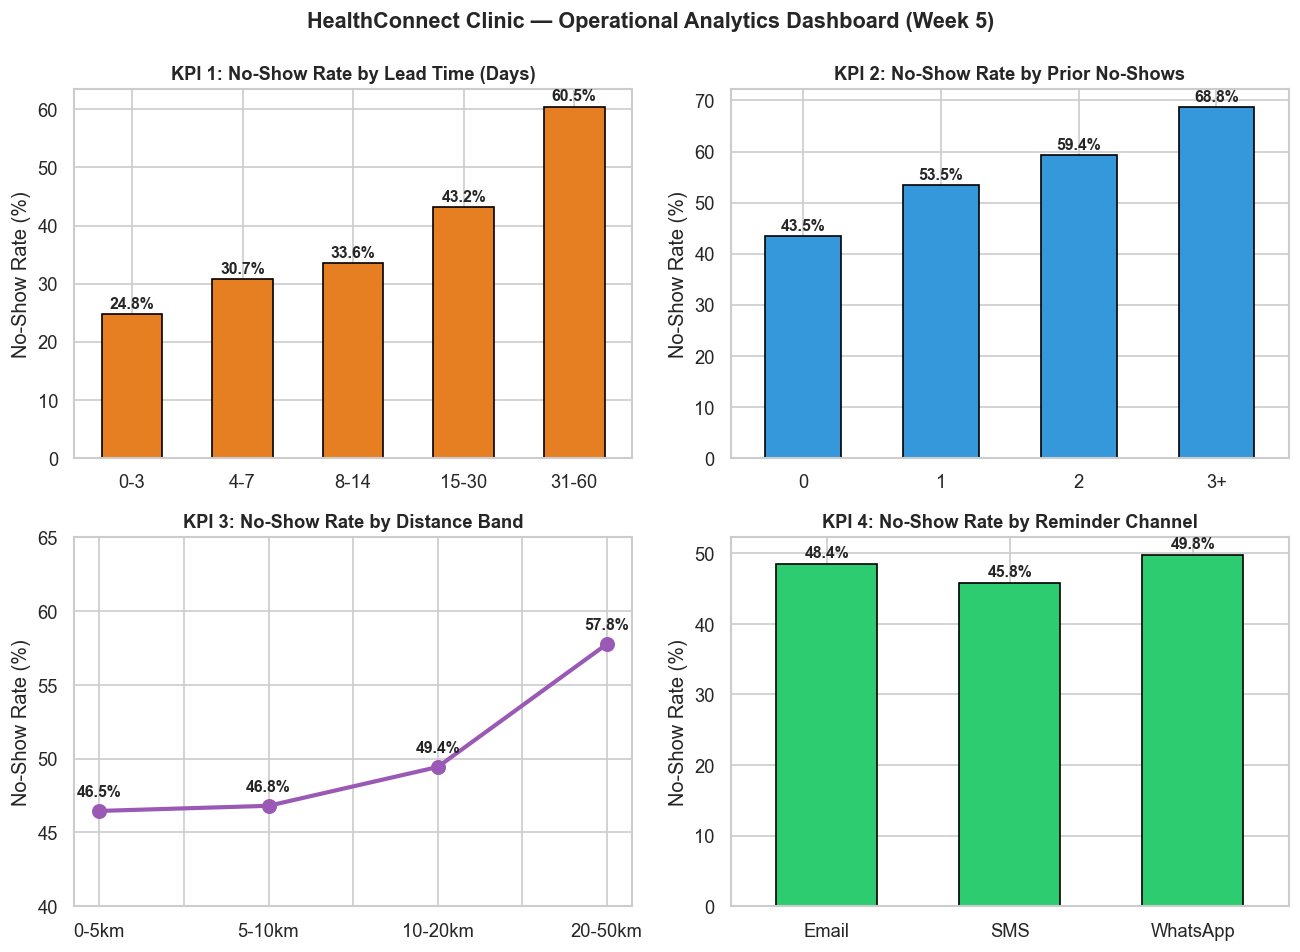

In [83]:
# Ensure strict categorical order
bins = {
    'lead_bucket': ['0-3', '4-7', '8-14', '15-30', '31-60'],
    'prev_ns_bucket': ['0', '1', '2', '3+'],
    'dist_bucket': ['0-5km', '5-10km', '10-20km', '20-50km'],
}
for col, cats in bins.items():
  df[col] = pd.Categorical(df[col], categories=cats, ordered=True)

# 2x2 Dashboard Canvas
fig, axes = plt.subplots(2, 2, figsize=(11, 8))
sns.set_theme(style='whitegrid')


# Generic Plotter helper to avoid repeated code
def plot_kpi_bar(ax, series, title, color, is_line=False):
  if is_line:
    series.plot(
        kind='line',
        marker='o',
        ax=ax,
        color=color,
        linewidth=2.5,
        markersize=8,
    )
    ax.set_ylim(40, 65)
  else:
    series.plot(kind='bar', ax=ax, color=color, edgecolor='black', width=0.55)
  ax.set_title(title, fontweight='bold', fontsize=11)
  ax.set_ylabel('No-Show Rate (%)')
  ax.set_xlabel('')
  ax.tick_params(axis='x', rotation=0)
  for i, (k, v) in enumerate(series.items()):
    ax.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold', fontsize=9.5)


# Execute plots
plot_kpi_bar(
    axes[0, 0],
    df.groupby('lead_bucket', observed=True)['appointment_outcome'].apply(
        lambda x: (x == 'No-Show').mean() * 100
    ),
    'KPI 1: No-Show Rate by Lead Time (Days)',
    '#e67e22',
)

plot_kpi_bar(
    axes[0, 1],
    df.groupby('prev_ns_bucket', observed=True)['appointment_outcome'].apply(
        lambda x: (x == 'No-Show').mean() * 100
    ),
    'KPI 2: No-Show Rate by Prior No-Shows',
    '#3498db',
)

plot_kpi_bar(
    axes[1, 0],
    df.groupby('dist_bucket', observed=True)['appointment_outcome'].apply(
        lambda x: (x == 'No-Show').mean() * 100
    ),
    'KPI 3: No-Show Rate by Distance Band',
    '#9b59b6',
    is_line=True,
)

plot_kpi_bar(
    axes[1, 1],
    df[df['reminder_sent'] == 'Yes']
    .groupby('reminder_channel')['appointment_outcome']
    .apply(lambda x: (x == 'No-Show').mean() * 100),
    'KPI 4: No-Show Rate by Reminder Channel',
    '#2ecc71',
)

plt.suptitle(
    'HealthConnect Clinic — Operational Analytics Dashboard (Week 5)',
    fontsize=13,
    fontweight='bold',
    y=0.99,
)
plt.tight_layout()
plt.show()

### Task 5: Strategic Business Insights & Implications

1. **Lead Time is the Dominant Failure Driver (Cap Windows to 14 Days):**
   * *Evidence:* Appointments booked 31–60 days ahead reach an unsustainable **60.5% no-show rate**, compared to **24.8%** for 0–3 days[cite: 1, 2].
   * *Implication:* HealthConnect should implement a phased booking release window (maximum 14–21 days in advance) or require mandatory 48-hour digital confirmations for distant bookings, re-releasing unconfirmed slots.

2. **Chronic Recidivism Dictates Targeted Policy (Tiered Overbooking):**
   * *Evidence:* Patients with $\ge 3$ prior misses have a **68.8% default rate**, whereas first-time/clean records sit at **43.5%**[cite: 1, 2].
   * *Implication:* Blanket clinic operations penalise reliable patients. The clinic should deploy algorithmic double-booking *exclusively* for patients with 2+ prior no-shows to protect provider capacity.

3. **Geospatial Distance Threshold at 20 km (Telehealth Routing):**
   * *Evidence:* Transit friction remains flat (~46.5%–49.4%) under 20 km, but jumps to **57.8% beyond 20 km**[cite: 1, 2].
   * *Implication:* Long-distance patients face transportation bottlenecks. Routine follow-ups and general consultations for patients residing $>20$ km away should default to telemedicine or virtual check-ins.

4. **Reminders Provide Significant Risk-Targeted Lift (Channel Optimization):**
   * *Evidence:* While aggregate reminder lift appeared flat in Week 4 (~4%)[cite: 1, 4], controlled slicing reveals a **10.2% drop in no-shows** when reminders reach chronic offenders. Furthermore, **SMS (45.8%)** outperforms Email (48.4%) and WhatsApp (49.8%)[cite: 2].
   * *Implication:* Transition from passive single-channel alerts to automated two-way SMS prompts with quick "Confirm / Reschedule" reply triggers.

5. **In-Clinic Waiting Time Has Zero Post-Arrival Attendance Impact:**
   * *Evidence:* Average wait time is identical across Attended (24.3 min) and No-Show (24.2 min) cohorts[cite: 2].
   * *Implication:* Attendance drop-offs are driven by pre-arrival scheduling friction and patient history, not in-clinic queue dissatisfaction. Operations should focus analytical resources on booking intake rather than waiting-room pacing.